# TILDA Texture Classification

Single notebook pipeline for the MODIA ML 2026 Kaggle challenge.

Constraints used here:
- no pretrained models;
- no transfer learning;
- grayscale TIFF images;
- internal labels are `0..7`, Kaggle submission labels are `1..8`.


## 1. Setup

In [1]:
from pathlib import Path
import random
import time

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = ROOT / 'data'
OUTPUT_DIR = ROOT / 'outputs'
CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'
SUBMISSION_DIR = OUTPUT_DIR / 'submissions'
FIGURE_DIR = OUTPUT_DIR / 'figures'

for p in [CHECKPOINT_DIR, SUBMISSION_DIR, FIGURE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE

device(type='cuda')

In [2]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())


2.12.0+cu126
12.6
True


## 2. Load Metadata

Expected data layout:

```text
data/train.csv
data/train/*.tif
data/test/*.tif
```

In [3]:
train_csv = DATA_DIR / 'train.csv'
train_dir = DATA_DIR / 'train'
test_dir = DATA_DIR / 'test'

df = pd.read_csv(train_csv, sep=';')
df['id'] = df['id'].astype(int)
df['label'] = df['label'].astype(int)
df['path'] = df['id'].map(lambda x: train_dir / f'{x}.tif')

print(df.head())
print(df['label'].value_counts().sort_index())
print('Train images:', len(df))
print('Test images:', len(list(test_dir.glob('*.tif'))))

   id  label                                               path
0   1      4  /home/onyxia/work/tilda-texture-classification...
1   2      6  /home/onyxia/work/tilda-texture-classification...
2   3      7  /home/onyxia/work/tilda-texture-classification...
3   4      6  /home/onyxia/work/tilda-texture-classification...
4   5      7  /home/onyxia/work/tilda-texture-classification...
label
0    300
1    300
2    262
3    300
4    300
5    299
6    300
7    300
Name: count, dtype: int64
Train images: 2361
Test images: 789


## 3. Quick Visual Check

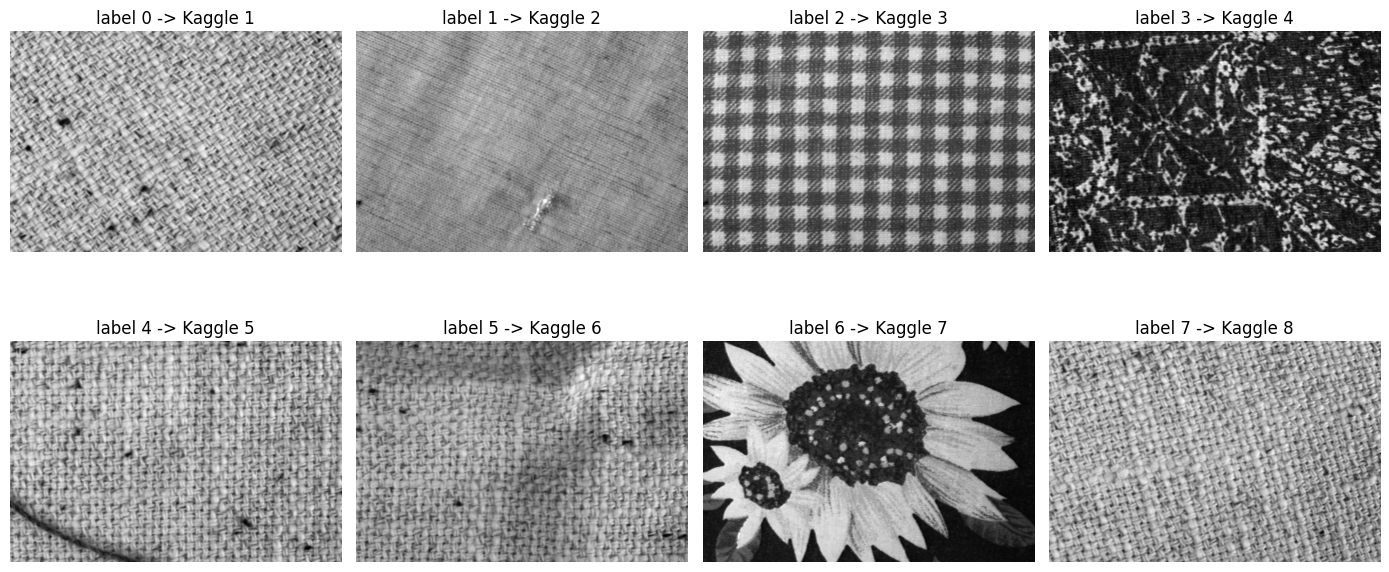

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, label in zip(axes.ravel(), sorted(df['label'].unique())):
    row = df[df['label'] == label].sample(1, random_state=SEED).iloc[0]
    img = Image.open(row['path']).convert('L')
    ax.imshow(img, cmap='gray')
    ax.set_title(f'label {label} -> Kaggle {label + 1}')
    ax.axis('off')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'samples_by_class.png', dpi=150)
plt.show()

## 4. Split + Transforms

Augmentation is applied only to the training split. Validation/test use deterministic preprocessing.

In [ ]:
IMG_SIZE = (512, 384)  # height, width; higher resolution for texture details
BATCH_SIZE = 32        # safer for heavier models at 512x384
NUM_WORKERS = 0        # more stable in Jupyter/Onyxia than multiprocessing workers

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df['label'],
)

train_tfms = transforms.Compose([
    transforms.Resize((576, 432)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.03, 0.03), scale=(0.95, 1.05), shear=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
    transforms.RandomErasing(p=0.20, scale=(0.01, 0.07), ratio=(0.3, 3.3)),
])

eval_tfms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

len(train_df), len(val_df)


## 5. Dataset + DataLoaders

In [6]:
class TildaDataset(Dataset):
    def __init__(self, dataframe=None, image_dir=None, ids=None, transform=None, has_labels=True):
        self.dataframe = dataframe.reset_index(drop=True) if dataframe is not None else None
        self.image_dir = Path(image_dir) if image_dir is not None else None
        self.ids = list(ids) if ids is not None else None
        self.transform = transform
        self.has_labels = has_labels

    def __len__(self):
        return len(self.dataframe) if self.has_labels else len(self.ids)

    def __getitem__(self, idx):
        if self.has_labels:
            row = self.dataframe.iloc[idx]
            image_id = int(row['id'])
            path = Path(row['path'])
            label = int(row['label'])
        else:
            image_id = int(self.ids[idx])
            path = self.image_dir / f'{image_id}.tif'
            label = -1

        image = Image.open(path).convert('L')
        if self.transform is not None:
            image = self.transform(image)

        return image, label, image_id


train_ds = TildaDataset(train_df, transform=train_tfms, has_labels=True)
val_ds = TildaDataset(val_df, transform=eval_tfms, has_labels=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

xb, yb, ids = next(iter(train_loader))
xb.shape, yb[:8]

(torch.Size([64, 1, 384, 256]), tensor([4, 4, 2, 2, 7, 0, 1, 5]))

## 6. Models From Scratch

Heavy run, still respecting the project constraint: all models are trained from scratch, without pretrained weights and without transfer learning.

Models included:

- `SmallResNet`: current best baseline.
- `ResNet18Scratch`: standard ResNet-18 style model adapted to grayscale.
- `ResNet34Scratch`: deeper standard residual model.
- `WideResNet16x8`: wider residual model, often strong on small/medium datasets.
- `WideResNet28x10`: heavier wide residual model for the A6000 run.


In [13]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout) if dropout > 0 else nn.Identity(),
        )

    def forward(self, x):
        return self.net(x)


class TextureCNN(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(1, 32, dropout=0.05),
            ConvBlock(32, 64, dropout=0.05),
            ConvBlock(64, 128, dropout=0.10),
            ConvBlock(128, 256, dropout=0.10),
            ConvBlock(256, 384, dropout=0.15),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.35),
            nn.Linear(384, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, dropout=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
        self.shortcut = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out = self.relu(out + identity)
        return out


class SmallResNet(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=2, padding=2, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        self.layer1 = nn.Sequential(ResidualBlock(32, 32), ResidualBlock(32, 32, dropout=0.05))
        self.layer2 = nn.Sequential(ResidualBlock(32, 64, stride=2), ResidualBlock(64, 64, dropout=0.05))
        self.layer3 = nn.Sequential(ResidualBlock(64, 128, stride=2), ResidualBlock(128, 128, dropout=0.10))
        self.layer4 = nn.Sequential(ResidualBlock(128, 256, stride=2), ResidualBlock(256, 256, dropout=0.15))
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.35),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        return self.head(x)


class ResNetBasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, dropout=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
        self.downsample = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        identity = self.downsample(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        return self.relu(out + identity)


class ResNetScratch(nn.Module):
    def __init__(self, layers, num_classes=8, base_width=64, dropout=0.10):
        super().__init__()
        self.in_channels = base_width
        self.stem = nn.Sequential(
            nn.Conv2d(1, base_width, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(base_width),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )
        self.layer1 = self._make_layer(base_width, layers[0], stride=1, dropout=dropout)
        self.layer2 = self._make_layer(base_width * 2, layers[1], stride=2, dropout=dropout)
        self.layer3 = self._make_layer(base_width * 4, layers[2], stride=2, dropout=dropout)
        self.layer4 = self._make_layer(base_width * 8, layers[3], stride=2, dropout=dropout)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.35),
            nn.Linear(base_width * 8, num_classes),
        )

    def _make_layer(self, out_channels, blocks, stride, dropout):
        layers = [ResNetBasicBlock(self.in_channels, out_channels, stride=stride, dropout=dropout)]
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(ResNetBasicBlock(self.in_channels, out_channels, stride=1, dropout=dropout))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        return self.head(x)


class ResNet18Scratch(ResNetScratch):
    def __init__(self, num_classes=8):
        super().__init__([2, 2, 2, 2], num_classes=num_classes, base_width=64, dropout=0.08)


class ResNet34Scratch(ResNetScratch):
    def __init__(self, num_classes=8):
        super().__init__([3, 4, 6, 3], num_classes=num_classes, base_width=64, dropout=0.08)


class WideBasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, dropout=0.0):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu2 = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.shortcut = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False)

    def forward(self, x):
        out = self.relu1(self.bn1(x))
        shortcut = self.shortcut(out if not isinstance(self.shortcut, nn.Identity) else x)
        out = self.conv1(out)
        out = self.relu2(self.bn2(out))
        out = self.dropout(out)
        out = self.conv2(out)
        return out + shortcut


class WideResNet(nn.Module):
    def __init__(self, depth=28, widen_factor=10, dropout=0.20, num_classes=8):
        super().__init__()
        assert (depth - 4) % 6 == 0, 'WideResNet depth should be 6n + 4'
        n = (depth - 4) // 6
        widths = [32, 32 * widen_factor, 64 * widen_factor, 128 * widen_factor]
        self.conv1 = nn.Conv2d(1, widths[0], kernel_size=3, padding=1, bias=False)
        self.block1 = self._make_group(widths[0], widths[1], n, stride=2, dropout=dropout)
        self.block2 = self._make_group(widths[1], widths[2], n, stride=2, dropout=dropout)
        self.block3 = self._make_group(widths[2], widths[3], n, stride=2, dropout=dropout)
        self.bn = nn.BatchNorm2d(widths[3])
        self.relu = nn.ReLU(inplace=True)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.35),
            nn.Linear(widths[3], num_classes),
        )

    def _make_group(self, in_channels, out_channels, blocks, stride, dropout):
        layers = [WideBasicBlock(in_channels, out_channels, stride=stride, dropout=dropout)]
        for _ in range(1, blocks):
            layers.append(WideBasicBlock(out_channels, out_channels, stride=1, dropout=dropout))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.relu(self.bn(x))
        return self.head(x)


class WideResNet16x8(WideResNet):
    def __init__(self, num_classes=8):
        super().__init__(depth=16, widen_factor=8, dropout=0.20, num_classes=num_classes)


class WideResNet28x10(WideResNet):
    def __init__(self, num_classes=8):
        super().__init__(depth=28, widen_factor=10, dropout=0.25, num_classes=num_classes)


MODEL_REGISTRY = {
    'small_resnet': SmallResNet,
    'resnet18_scratch': ResNet18Scratch,
    'resnet34_scratch': ResNet34Scratch,
    'wide_resnet16x8': WideResNet16x8,
    'wide_resnet28x10': WideResNet28x10,
}


def build_model(model_name, num_classes=8):
    if model_name not in MODEL_REGISTRY:
        raise ValueError(f'Unknown model: {model_name}')
    return MODEL_REGISTRY[model_name](num_classes=num_classes)


for name in MODEL_REGISTRY:
    model = build_model(name).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters())
    print(f'{name:18s}: {n_params:,} parameters')
    del model
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()


small_resnet      : 2,797,032 parameters
resnet18_scratch  : 11,174,344 parameters
resnet34_scratch  : 21,282,504 parameters
wide_resnet16x8   : 43,817,320 parameters
wide_resnet28x10  : 145,864,040 parameters


## 7. Training Loop

In [14]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.set_grad_enabled(is_train):
        for images, labels, _ in tqdm(loader, leave=False):
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            all_preds.extend(logits.argmax(dim=1).detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc


def train_model(model, train_loader, val_loader, model_name, epochs=160, lr=0.03, weight_decay=5e-4, patience=40):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9,
        weight_decay=weight_decay,
        nesterov=True,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

    history = []
    best_acc = -1.0
    best_epoch = 0
    best_path = CHECKPOINT_DIR / f'best_{model_name}.pt'
    start = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)
        scheduler.step()

        row = {
            'model': model_name,
            'epoch': epoch,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'lr': scheduler.get_last_lr()[0],
        }
        history.append(row)

        if val_acc > best_acc:
            best_acc = val_acc
            best_epoch = epoch
            torch.save({
                'model_name': model_name,
                'model_state_dict': model.state_dict(),
                'history': history,
                'best_acc': best_acc,
                'best_epoch': best_epoch,
                'img_size': IMG_SIZE,
                'optimizer': 'SGD(momentum=0.9, nesterov=True)',
            }, best_path)

        print(
            f"{model_name} | Epoch {epoch:03d} | "
            f"train {train_acc:.4f}/{train_loss:.4f} | "
            f"val {val_acc:.4f}/{val_loss:.4f} | "
            f"best {best_acc:.4f} @ {best_epoch}"
        )

        if epoch - best_epoch >= patience:
            print(f'{model_name}: early stopping after {patience} epochs without validation improvement.')
            break

    elapsed_min = (time.time() - start) / 60
    print(f'{model_name}: training time {elapsed_min:.1f} min, best validation accuracy {best_acc:.4f}')
    return pd.DataFrame(history), best_path, best_acc, best_epoch, elapsed_min


## 8. Train All Models

This cell trains all selected models sequentially. On EDiTO/A6000, keep the full list. For a quick smoke test, reduce `epochs` to `2` or keep only one experiment.


In [15]:
EXPERIMENTS = [
    {'name': 'small_resnet', 'epochs': 180, 'lr': 0.030, 'weight_decay': 5e-4, 'patience': 45},
    {'name': 'resnet18_scratch', 'epochs': 180, 'lr': 0.030, 'weight_decay': 5e-4, 'patience': 45},
    {'name': 'resnet34_scratch', 'epochs': 200, 'lr': 0.025, 'weight_decay': 5e-4, 'patience': 50},
    {'name': 'wide_resnet16x8', 'epochs': 180, 'lr': 0.030, 'weight_decay': 5e-4, 'patience': 45},
    {'name': 'wide_resnet28x10', 'epochs': 220, 'lr': 0.020, 'weight_decay': 5e-4, 'patience': 55},
]

all_histories = {}
all_checkpoints = {}
all_results = []

for exp in EXPERIMENTS:
    model_name = exp['name']
    print('\n' + '=' * 80)
    print(f'Training {model_name}')
    print('=' * 80)

    model = build_model(model_name).to(DEVICE)
    history, best_path, best_acc, best_epoch, elapsed_min = train_model(
        model,
        train_loader,
        val_loader,
        model_name=model_name,
        epochs=exp['epochs'],
        lr=exp['lr'],
        weight_decay=exp['weight_decay'],
        patience=exp['patience'],
    )

    history_path = OUTPUT_DIR / f'history_{model_name}.csv'
    history.to_csv(history_path, index=False)

    all_histories[model_name] = history
    all_checkpoints[model_name] = best_path
    all_results.append({
        'model': model_name,
        'best_val_acc': best_acc,
        'best_epoch': best_epoch,
        'training_time_min': elapsed_min,
        'checkpoint': str(best_path),
        'history': str(history_path),
    })

    del model
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

results_df = pd.DataFrame(all_results).sort_values('best_val_acc', ascending=False)
results_path = OUTPUT_DIR / 'model_results_heavy.csv'
results_df.to_csv(results_path, index=False)
results_df



Training small_resnet


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

small_resnet | Epoch 001 | train 0.1541/2.1761 | val 0.1438/13.2301 | best 0.1438 @ 1


  0%|          | 0/30 [00:00<?, ?it/s]

...

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

wide_resnet16x8 | Epoch 180 | train 0.6907/0.9839 | val 0.7230/0.9383 | best 0.7378 @ 167
wide_resnet16x8: training time 172.7 min, best validation accuracy 0.7378

Training wide_resnet28x10


  0%|          | 0/30 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 960.00 MiB. GPU 0 has a total capacity of 47.74 GiB of which 386.94 MiB is free. Process 155883 has 43.73 GiB memory in use. Of the allocated memory 43.34 GiB is allocated by PyTorch, and 63.41 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

## 9. Validation Diagnostics


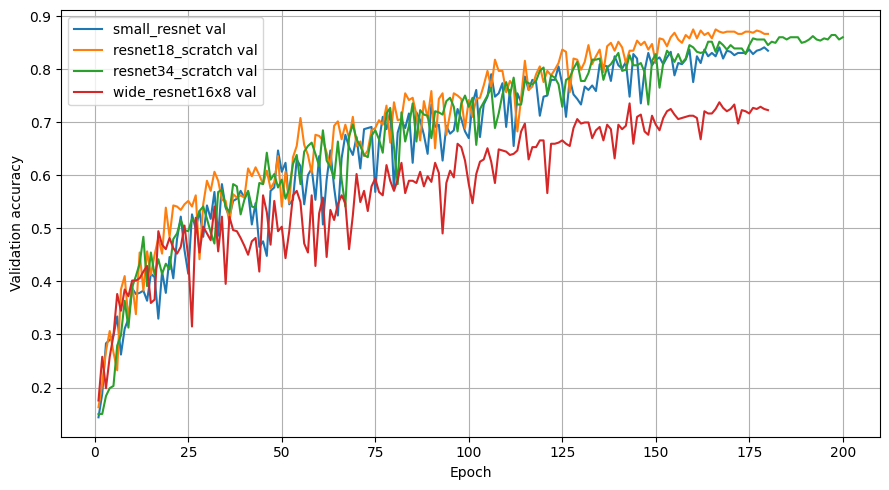

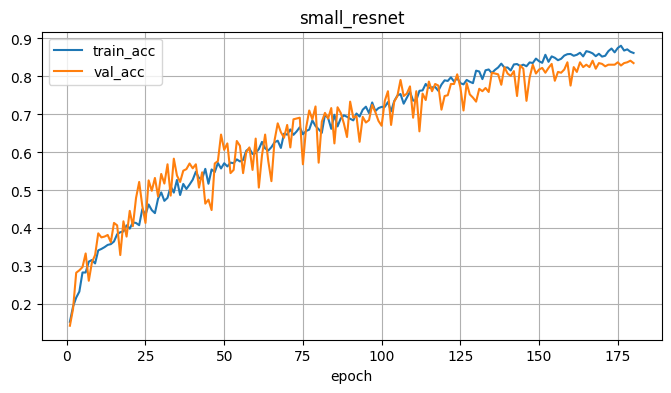

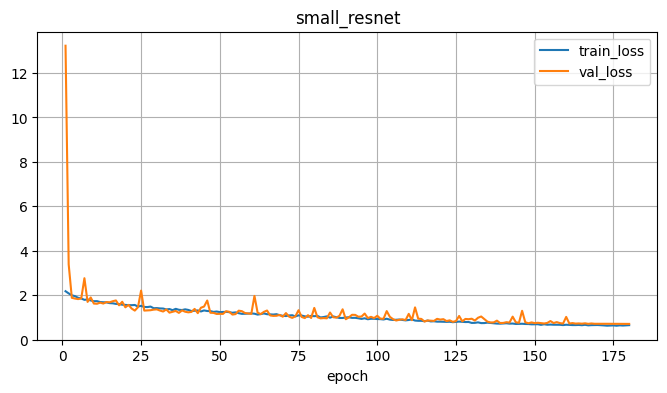

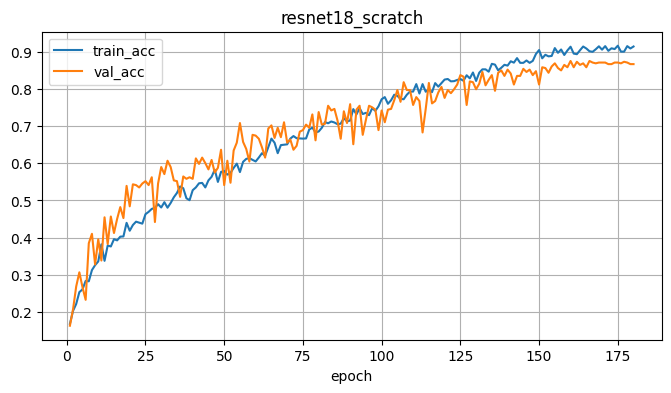

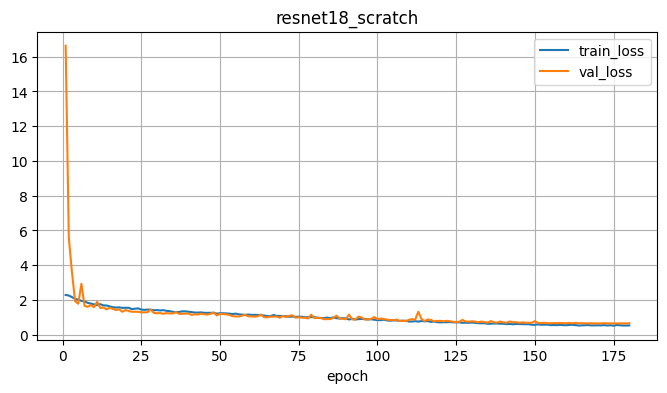

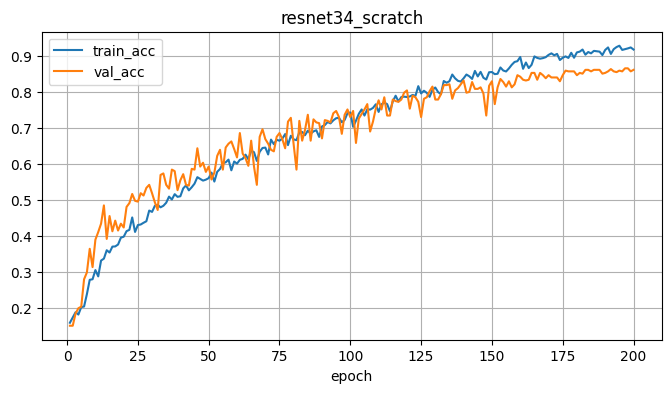

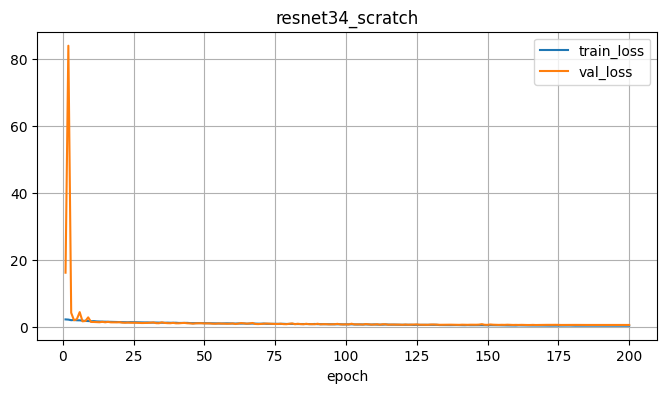

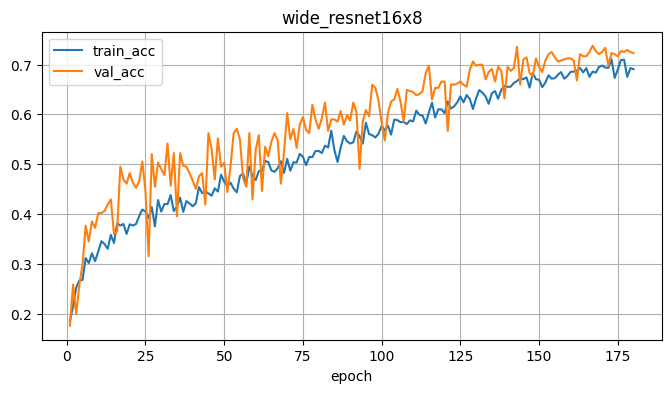

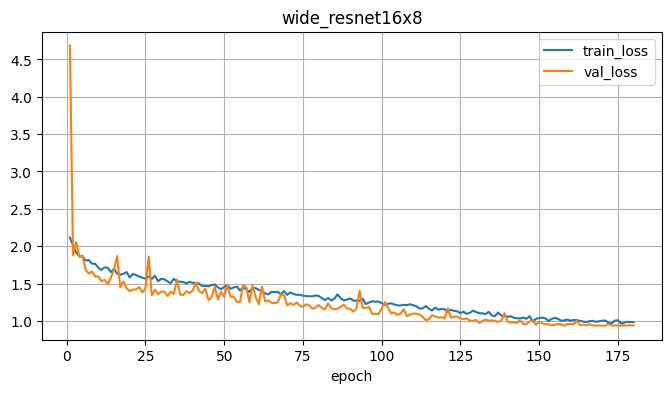

In [16]:
# Plot all validation curves together.
fig, ax = plt.subplots(figsize=(9, 5))
for model_name, history in all_histories.items():
    ax.plot(history['epoch'], history['val_acc'], label=f'{model_name} val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation accuracy')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'all_validation_accuracy.png', dpi=150)
plt.show()

# Plot train/val curves for each model.
for model_name, history in all_histories.items():
    history.plot(x='epoch', y=['train_acc', 'val_acc'], figsize=(8, 4), grid=True, title=model_name)
    plt.savefig(FIGURE_DIR / f'accuracy_curve_{model_name}.png', dpi=150)
    plt.show()

    history.plot(x='epoch', y=['train_loss', 'val_loss'], figsize=(8, 4), grid=True, title=model_name)
    plt.savefig(FIGURE_DIR / f'loss_curve_{model_name}.png', dpi=150)
    plt.show()


In [17]:
best_model_name = results_df.iloc[0]['model']
best_path = Path(results_df.iloc[0]['checkpoint'])
print('Best model:', best_model_name)
print('Best checkpoint:', best_path)

model = build_model(best_model_name).to(DEVICE)
checkpoint = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

val_preds, val_labels = [], []
with torch.no_grad():
    for images, labels, _ in val_loader:
        images = images.to(DEVICE, non_blocking=True)
        logits = model(images)
        val_preds.extend(logits.argmax(dim=1).cpu().numpy())
        val_labels.extend(labels.numpy())

print('Best validation accuracy:', accuracy_score(val_labels, val_preds))
cm = confusion_matrix(val_labels, val_preds, labels=list(range(8)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[str(i + 1) for i in range(8)])
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title(f'Validation confusion matrix: {best_model_name}, Kaggle labels 1..8')
plt.savefig(FIGURE_DIR / f'confusion_matrix_{best_model_name}.png', dpi=150)
plt.show()


Best model: small_resnet
Best checkpoint: /home/onyxia/work/tilda-texture-classification/outputs/checkpoints/best_small_resnet.pt


OutOfMemoryError: CUDA out of memory. Tried to allocate 192.00 MiB. GPU 0 has a total capacity of 47.74 GiB of which 166.94 MiB is free. Process 155883 has 43.95 GiB memory in use. Of the allocated memory 43.57 GiB is allocated by PyTorch, and 55.88 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

## 10. Predict Test + Create Submissions

This creates one CSV per heavy model and two ensemble CSV files:

- `submission_ensemble_top3_models.csv`: averages only the best 3 validation models.
- `submission_ensemble_all_models.csv`: averages all trained heavy models.

Kaggle expects labels `1..8`, while models predict `0..7`.


In [18]:
def predict_proba(model, loader, use_tta=True):
    model.eval()
    all_probs = []
    all_ids = []

    with torch.no_grad():
        for images, _, image_ids in tqdm(loader, leave=False):
            images = images.to(DEVICE, non_blocking=True)
            logits_list = [model(images)]

            if use_tta:
                logits_list.append(model(torch.flip(images, dims=[-1])))       # horizontal flip
                logits_list.append(model(torch.flip(images, dims=[-2])))       # vertical flip
                logits_list.append(model(torch.flip(images, dims=[-2, -1])))   # both flips

            probs = torch.stack([torch.softmax(logits, dim=1) for logits in logits_list]).mean(dim=0)
            all_probs.append(probs.cpu())
            all_ids.extend(image_ids.numpy().tolist())

    return torch.cat(all_probs, dim=0).numpy(), np.array(all_ids)


test_ids = sorted([int(p.stem) for p in test_dir.glob('*.tif')])
test_ds = TildaDataset(image_dir=test_dir, ids=test_ids, transform=eval_tfms, has_labels=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

USE_TTA = True
model_probabilities = {}
ids_reference = None

for _, row in results_df.iterrows():
    model_name = row['model']
    checkpoint_path = Path(row['checkpoint'])
    print(f'Predicting test set with {model_name} from {checkpoint_path}')

    model = build_model(model_name).to(DEVICE)
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])

    probs, ids = predict_proba(model, test_loader, use_tta=USE_TTA)
    if ids_reference is None:
        ids_reference = ids
    else:
        assert np.array_equal(ids_reference, ids)

    preds = probs.argmax(axis=1) + 1
    submission = pd.DataFrame({'id': ids, 'label': preds}).sort_values('id')
    submission_path = SUBMISSION_DIR / f'submission_{model_name}.csv'
    submission.to_csv(submission_path, index=False)
    print('Saved:', submission_path)

    model_probabilities[model_name] = probs

    del model
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()


def save_ensemble(model_names, filename):
    probs = np.mean([model_probabilities[name] for name in model_names], axis=0)
    preds = probs.argmax(axis=1) + 1
    submission = pd.DataFrame({'id': ids_reference, 'label': preds}).sort_values('id')
    path = SUBMISSION_DIR / filename
    submission.to_csv(path, index=False)
    print('Saved ensemble:', path, 'models:', model_names)
    return submission

all_model_names = results_df['model'].tolist()
top3_model_names = results_df.head(3)['model'].tolist()

ensemble_top3 = save_ensemble(top3_model_names, 'submission_ensemble_top3_models.csv')
ensemble_all = save_ensemble(all_model_names, 'submission_ensemble_all_models.csv')
ensemble_top3.head()


Predicting test set with small_resnet from /home/onyxia/work/tilda-texture-classification/outputs/checkpoints/best_small_resnet.pt


  0%|          | 0/13 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 192.00 MiB. GPU 0 has a total capacity of 47.74 GiB of which 118.94 MiB is free. Process 155883 has 44.00 GiB memory in use. Of the allocated memory 43.60 GiB is allocated by PyTorch, and 67.75 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

## 11. Next Experiments

Submit in this order:

1. Best single model from `results_df`.
2. `outputs/submissions/submission_ensemble_top3_models.csv`.
3. `outputs/submissions/submission_ensemble_all_models.csv`.

If this heavy run improves clearly, the next serious step is 5-fold training with the best architecture only.
